<hr/>
<b>Nombre</b>: Jesus David Serpa Pajaro


##
 Enunciado

**Objetivo**: El objetivo de esta tarea es poner a prueba los resultados vistos en clase sobre las constantes en el problema de los N-cuerpos, en este caso aplicados al sistema solar.  Para ello usaremos el sistema de datos del JPL Horizons y el paquete `astroquery`.

**Procedimiento**:

Para conseguir el objetivo:

1. Obtener las masas, posiciones y velocidades de los planetas del sistema solar (8 planetas) y del Sol durante 20 años (por ejemplo entre 2000 y 2020), cada 3 meses. Use para ello Astroquery y SPICE (para las masas).

2. Para cada punto en el tiempo calcular:

   - El momentum lineal de cada cuerpo.
   - El momentum angular de cada cuerpo.
   - La energía cinética de cada cuerpo.
   - La energía potencial gravidtacional de todo el sistema.

3. Usando el valor de cada una de las cantidades anteriores vamos a calcular el valor de las cuadraturas del sistema:

   - Calcular el momentum lineal total (3 cuadraturas).
   - Calcular el momentum angular total (3 cuadraturas).
   - Calcular la energía total total (1 cuadratura).

   Es muy importante tener en cuenta que el valor de cada una de las cuadraturas puede ser inmenso (las masas del sistema solar son inmensas). Por lo tanto, debemos dividir cada cuadratura por el valor característico de. para ello calcule el valor promedio del momentum lineal, angular y energía cinética del Sol.

4. Hacer gráficos de las 10 cuadraturas.

5. El momentum angular total del sistema solar define el Plano de Laplace del sistema. El momentum angular de cada uno de los cuerpos del sistema solar define la inclinación de la órbita osculatriz del cuerpo respecto al plano de Laplace. Calcular, para cada tiempo, el ángulo entre el plano de Laplace y la órbita osculatriz de cada cuerpo (incluyendo el Sol).

Ayuda: el ángulo entre dos vectores se calcula usando la propiedad del producto punto A⋅ B = A B cos θ.

6. Haga un gráfico del ángulo de la órbita osculatriz de cada cuerpo como función del tiempo.

7. Calcule el valor promedio de la inclinación orbital de cada planeta en grados respecto al plano invariante de Laplace.


## Solución

importamos las librerias importantes

In [ ]:
!pip install -q pymcel

In [ ]:
!wget https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de440.tpc

--2023-08-29 17:17:06--  https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de440.tpc
Resolving naif.jpl.nasa.gov (naif.jpl.nasa.gov)... 137.78.232.95
Connecting to naif.jpl.nasa.gov (naif.jpl.nasa.gov)|137.78.232.95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12708 (12K) [text/plain]
Saving to: ‘gm_de440.tpc.4’

gm_de440.tpc.4      100%[===================>]  12.41K  --.-KB/s    in 0s      

2023-08-29 17:17:07 (165 MB/s) - ‘gm_de440.tpc.4’ saved [12708/12708]



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants
from astroquery.jplhorizons import Horizons
import pandas as pd
import spiceypy as spy
from datetime import datetime

In [ ]:
#constantes
G=constants.G.value
AU=constants.au.value

## 1.
 Obtener las masas, posiciones y velocidades de los planetas del sistema solar (8 planetas) y del Sol durante 20 años (por ejemplo entre 2000 y 2020), cada 3 meses. Use para ello Astroquery y SPICE (para las masas).


In [ ]:
#pasar de dias a canonica
τ=(1/86400)*(5033865)

In [ ]:
#obtener posiciones y velocidades
fechas = {'start': '2000-01-01', 'stop': '2020-01-01', 'step': '3months'}
planetas = ['Sol','Mercurio','venus','Tierra','marte','Jupiter','Saturno','Urano','Neptuno']
Coordenadas=['X',"Y",'Z']

#Sacamos la posicion y la velocidad el sol
r_sun = np.array([Horizons(10, location='@0', epochs=fechas).vectors().to_pandas()[["x","y","z"]]])
v_sun = np.array([Horizons(10, location='@0', epochs=fechas).vectors().to_pandas()[["vx","vy","vz"]]])

#sacamos la posicion y las velocidades de los plentas
rs = np.array([Horizons(f'{i}99', location='@0', epochs=fechas).vectors().to_pandas()[["x","y","z"]] for i in range(1,9)])
vs = np.array([Horizons(f'{i}99', location='@0', epochs=fechas).vectors().to_pandas()[["vx","vy","vz"]] for i in range(1,9)])

posiciones= np.concatenate((r_sun, rs))             #np.concatenate sirve para unir los arrays
velocidades =np.concatenate((v_sun, vs))*τ

In [ ]:
#sacamos la lista de tiempo en datetime
tiempo = Horizons(10, location='@0', epochs=fechas).ephemerides()['datetime_str'].tolist()
tiempo = [datetime.strptime(ts, '%Y-%b-%d %H:%M') for ts in tiempo]

In [ ]:
4#obtener masas

#Cargar el kernel
spy.furnsh('gm_de440.tpc')

# MAsa del sol
n,dato = spy.bodvrd('10 ','GM',1)
msun = dato*1e3**3/(G)


masas = [msun]

#pasa sacar la masa de todos los planetas
for i in range(1,9):
  n,dato2 = spy.bodvrd(f'{i}99','GM',1)
  dato2 = dato2*1e3**3/G
  masas.append(dato2)

masas = np.array(masas)
masas = masas /msun
masas

array([[1.00000000e+00],
       [1.66012083e-07],
       [2.44783829e-06],
       [3.00348962e-06],
       [3.22715592e-07],
       [9.54594248e-04],
       [2.85815001e-04],
       [4.36579363e-05],
       [5.15031081e-05]])

## 2. Para cada punto en el tiempo calcular:

- El momentum lineal de cada cuerpo.

\begin{equation}
p⃗ = m * v
\end{equation}

In [ ]:
#calcular el momentum lineal

Ps=[]
for i in range(0,9):
  x=[]
  for j in velocidades[i]:
    a=masas[i]*j
    x.append(a)
  Ps.append(x)
#Ps

   - El momentum angular de cada cuerpo.



\begin{equation}
L⃗= m r⃗ × v⃗
\end{equation}

In [ ]:
#calcular el momentum angular

Ls=[]
for i in range(0,9):
  x=[]
  for vel, pos in zip(velocidades[i], posiciones[i]):
    a = masas[i] * np.cross(pos, vel)
    x.append(a)
  Ls.append(x)
#Ls

   - La energía cinética de cada cuerpo.




\begin{equation}
K = \frac{1}{2} m v⃗^2
\end{equation}

In [ ]:
#calcular el momentum linela

K=[]
for i in range(0,9):
  x=[]
  for j in velocidades[i]:
    v= np.linalg.norm(j)
    a= (1/2)*masas[i]*v**2
    x.append(a)
  K.append(x)
#k

   - La energía potencial gravidtacional de todo el sistema.

\begin{equation}
U = \frac{-GMm}{r}
\end{equation}

In [ ]:


Up = np.zeros(len(posiciones[0]))
for i in range(len(masas)):
  for j in range(len(masas)):
    if i!=j:
      rij= (posiciones[i]-posiciones[j])
      rij= np.linalg.norm(rij,axis=1)
      U= (1/2)*(- 1* masas[i] * masas[j] )/ rij
      Up +=U
#up

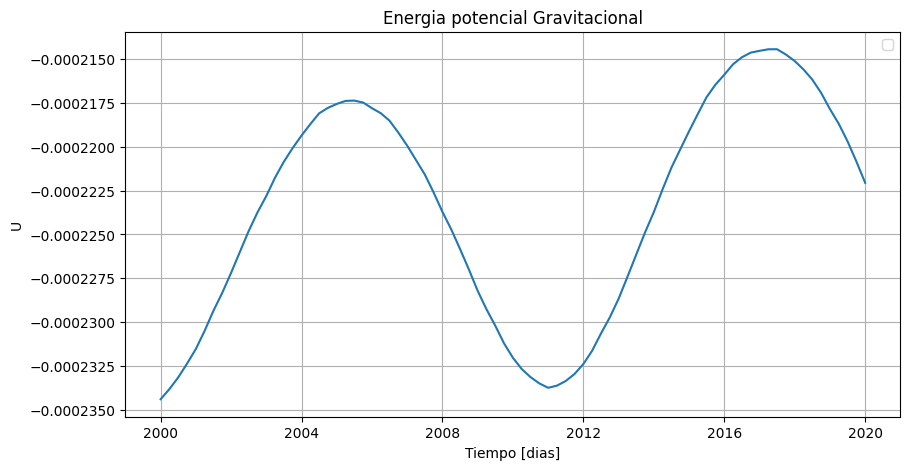

In [ ]:
#Grafico de la energia potencial gravitacional
plt.figure(figsize=(10,5))
plt.plot(tiempo,Up)
plt.title('Energia potencial Gravitacional')
plt.xlabel('Tiempo [dias]')
plt.ylabel('U')
plt.legend()
plt.grid()

* Calculo del centro de masa

\begin{equation}
  R⃗⃗_{CM} = \frac{mr - P_{cm}}{M}
\end{equation}

In [ ]:
Rcm=[]
for i in range (len(Ps)):
  a=[]
  for j in range(len(Ps[0])):
    x = masas[i]*posiciones[i][j] - Ps[i][j]*(90/τ)*i
    a.append(x)
  Rcm.append(a)
#Rcm

In [ ]:
#Saco la masa total siendo la suma de todas las masas de los planetas
M=0
for i in range(len(masas)):
  M += masas[i]

In [ ]:
#calcular Posicion del centro de masa total para cada componente
Rcmtotal = []

for i in range(0, 3):
    z = []
    for j in range(len(Ps[0])):
        a = 0
        for k in range(len(Ps)):
          a += Rcm[k][j][i]
        z.append(a)
    Rcmtotal.append(z)
Rcmtotal
Rcmtotal=np.array(Rcmtotal) / M
#Rcmtotal

## 3. Usando el valor de cada una de las cantidades anteriores vamos a calcular el valor de las cuadraturas del sistema:

   - Calcular el momentum lineal total (3 cuadraturas).


In [ ]:
#calcular el momentun lineal total para cada componente
Pt = []

for i in range(0, 3):
    z = []
    for j in range(len(Ps[0])):
        a = 0
        for k in range(len(Ps)):
          a += Ps[k][j][i]
        z.append(a)
    Pt.append(z)


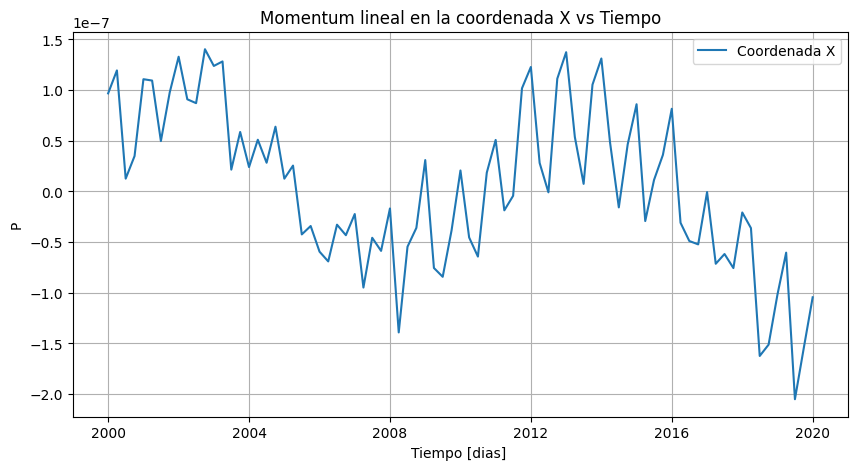

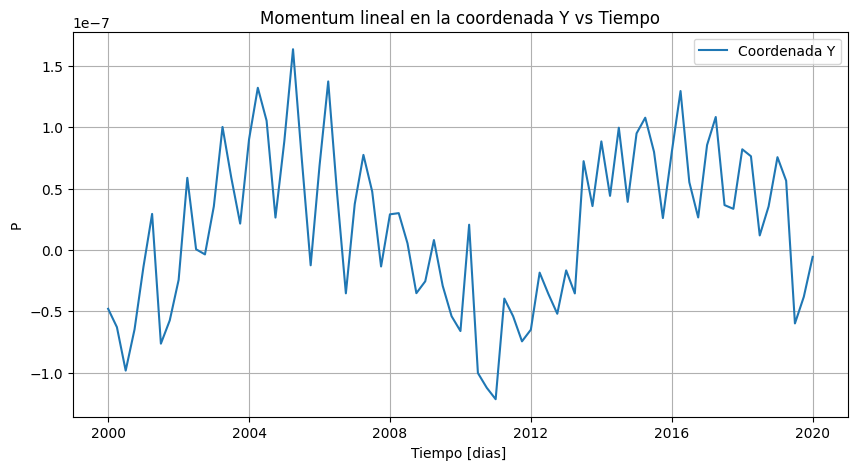

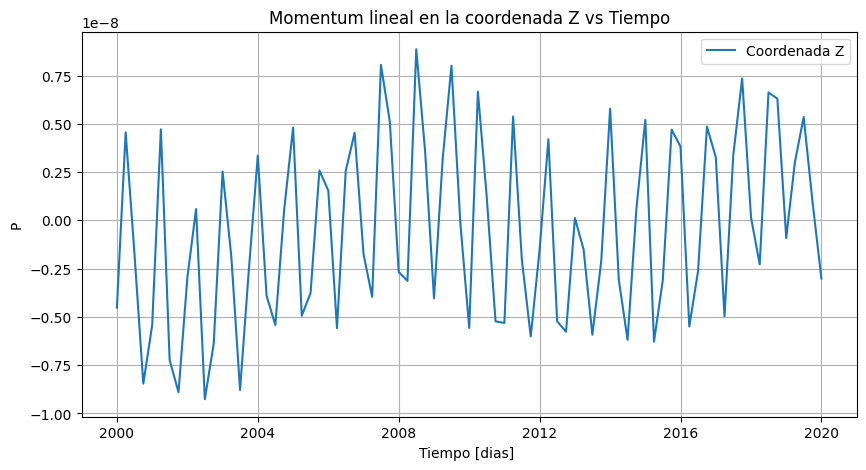

In [ ]:
for i in range(0,3):
  plt.figure(figsize=(10,5))
  plt.plot(tiempo, [Pt[i][j] for j in range(len(Ps[0]))], label=f'Coordenada {Coordenadas[i]}' )
  plt.title(f'Momentum lineal en la coordenada {Coordenadas[i]} vs Tiempo')
  plt.xlabel('Tiempo [dias] ')
  plt.ylabel('P')
  plt.legend()
  plt.grid()

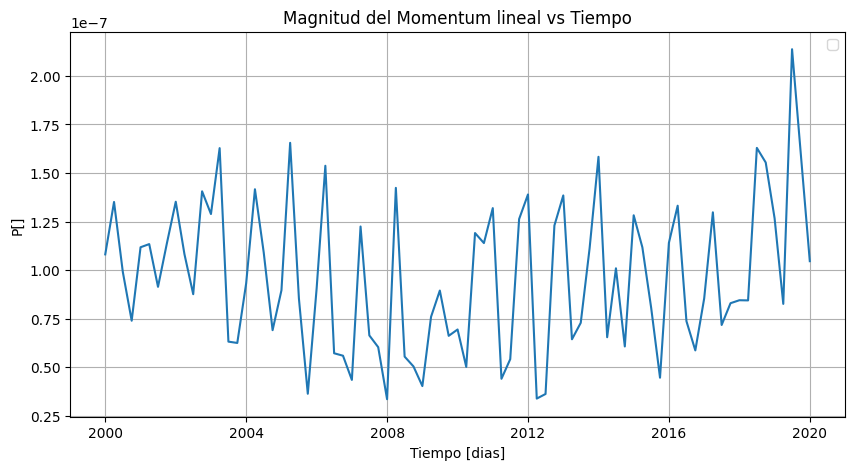

In [ ]:
#para el momentum lineal total juntamos las tres coordenadas para darnos el vector del momentum lineal total para luego graficarlo

Pmagnitud=[]
for i in range(len(Pt[0])):
  x=np.array([Pt[0][i],Pt[1][i],Pt[2][i]])
  a=np.linalg.norm(x,axis=0)
  Pmagnitud.append(a)

Ltotal=np.array(Pmagnitud)


plt.figure(figsize=(10,5))

plt.plot(tiempo,Pmagnitud)
plt.title(f'Magnitud del Momentum lineal vs Tiempo')
plt.xlabel('Tiempo [dias]')
plt.ylabel('P[]')
plt.legend()
plt.grid()


   - Calcular el momentum angular total (3 cuadraturas).


In [ ]:
Lt = []

for i in range(0, 3):
    z = []
    for j in range(len(Ls[0])):
        a = 0
        for k in range(len(Ls)):
          a += Ls[k][j][i]
        z.append(a)
    Lt.append(z)

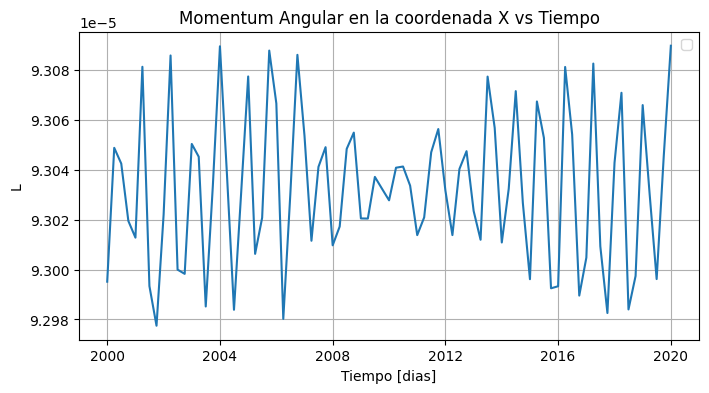

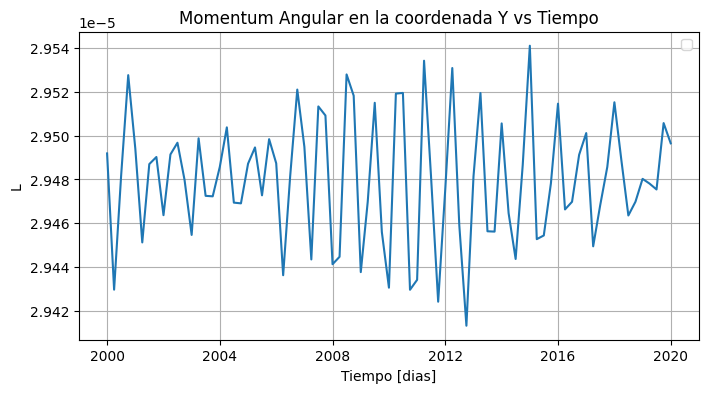

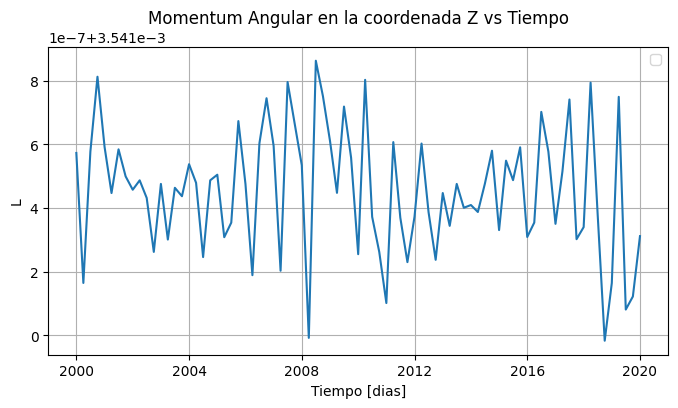

In [ ]:
t= np.array(range(len(Ls[0])))
for i in range(0,3):
  plt.figure(figsize=(8,4))
  plt.plot(tiempo, [Lt[i][j] for j in range(len(Ls[0]))])
  plt.title(f'Momentum Angular en la coordenada {Coordenadas[i]} vs Tiempo')
  plt.xlabel('Tiempo [dias]')
  plt.ylabel('L')
  plt.legend()
  plt.grid()

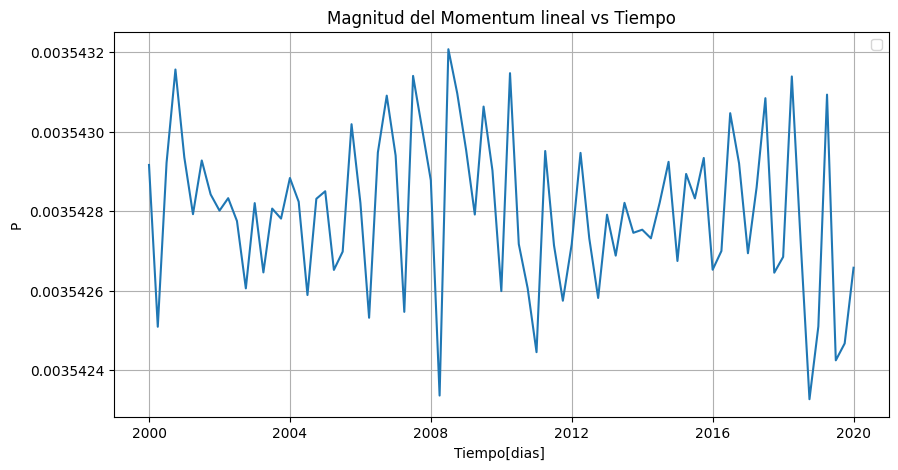

In [ ]:
#para el momentum Angular total juntamos las tres coordenadas para darnos el vector del momentum lineal total para luego graficarlo

Lmagnitud=[]
for i in range(len(Pt[0])):
  x=np.array([Lt[0][i],Lt[1][i],Lt[2][i]])
  a=np.linalg.norm(x,axis=0)
  Lmagnitud.append(a)

Ltotal=np.array(Lmagnitud)

#graficamos
plt.figure(figsize=(10,5))
plt.plot(tiempo,Lmagnitud )
plt.title(f'Magnitud del Momentum lineal vs Tiempo')
plt.xlabel('Tiempo[dias] ')
plt.ylabel('P')
plt.legend()
plt.grid()


 - Calcular la energía total total (1 cuadratura).

In [ ]:
#calculamos los valores de la energia cinetica total para cada instante de tiempo
Kt = []


for i in range(len(Ls[0])):
    a = 0
    for k in range(len(Ls)):
        a += K[k][i]
    Kt.append(a)

In [ ]:
#calculo de la Energia mecanica total que es la suma de la energia cinetica mas la potencial


E=[]
for i in range(len(Kt)):
  x = Kt[i] + (Up[i])
  E.append(x)


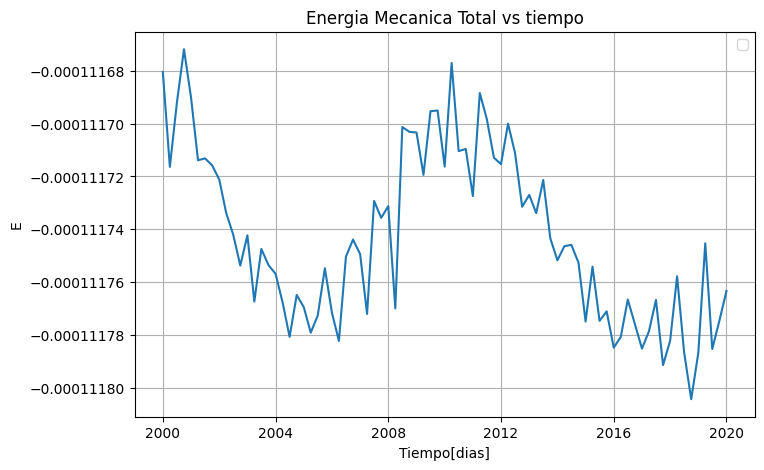

In [ ]:
#graficamos
plt.figure(figsize=(8,5))
plt.plot(tiempo,E)
plt.title(f'Energia Mecanica Total vs tiempo')
plt.xlabel('Tiempo[dias]')
plt.ylabel('E')
plt.legend()
plt.grid()

* Posicion del centro de masa (3 cuadraturas)

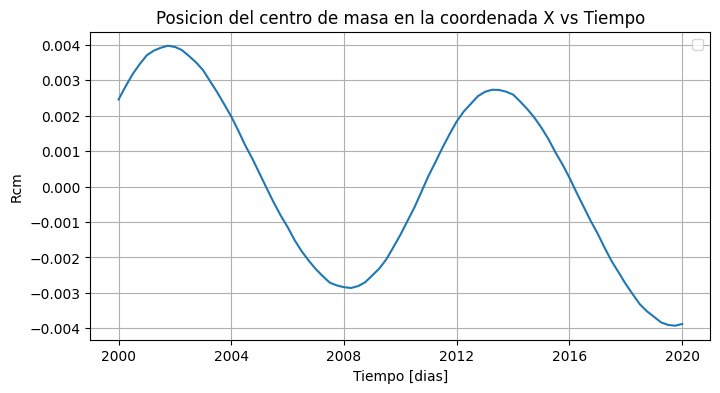

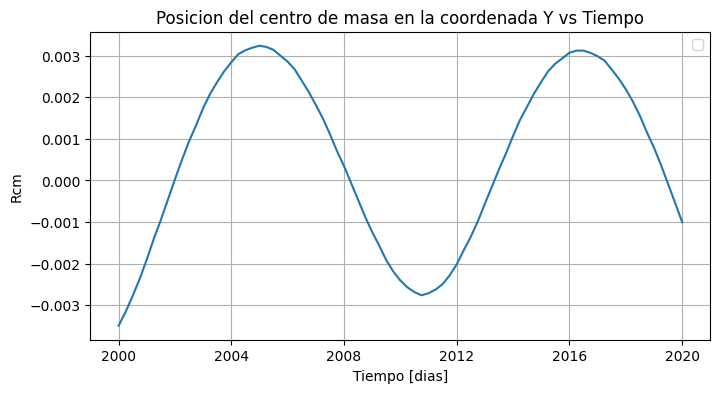

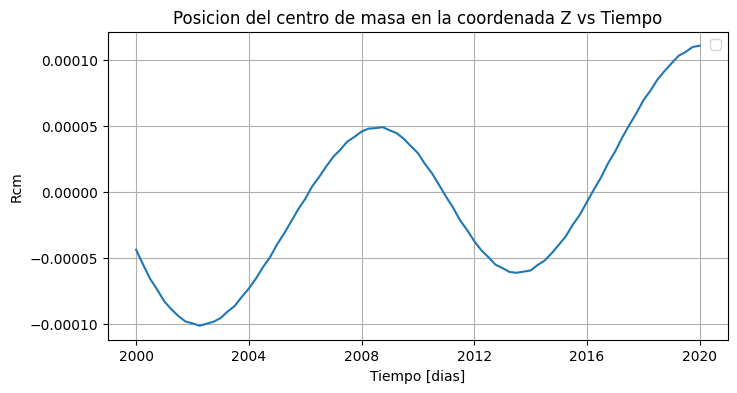

In [ ]:
for i in range(0,3):
  plt.figure(figsize=(8,4))
  plt.plot(tiempo, [Rcmtotal[i][j] for j in range(len(Rcmtotal[0]))])
  plt.title(f'Posicion del centro de masa en la coordenada {Coordenadas[i]} vs Tiempo')
  plt.xlabel('Tiempo [dias]')
  plt.ylabel('Rcm')
  plt.legend()
  plt.grid()

5. El momentum angular total del sistema solar define el Plano de Laplace del sistema. El momentum angular de cada uno de los cuerpos del sistema solar define la inclinación de la órbita osculatriz del cuerpo respecto al plano de Laplace. Calcular, para cada tiempo, el ángulo entre el plano de Laplace y la órbita osculatriz de cada cuerpo (incluyendo el Sol).

Ayuda: el ángulo entre dos vectores se calcula usando la propiedad del producto punto A⋅ B = A B cos θ.


Calculas el momentum total:

In [ ]:
#calculamos los valores de la energia cinetica total para cada instante de tiempo
Ltotal=[]
for i in range(len(Lt[0])):
  x=np.array([Lt[0][i],Lt[1][i],Lt[2][i]])

  #Agregamos el valor calcular
  Ltotal.append(x)

Ltotal=np.array(Ltotal)


In [ ]:
Ltotal= np.array(Ltotal)
Ls=np.array(Ls)
θ=[]

for i in range(len(Ls)):
  a=[]
  for j in range(len(Lt[0])):
    A= np.linalg.norm(Ls[i][j])
    B= np.linalg.norm(Ltotal[j])
    coseno = (np.dot(Ls[i][j], Ltotal[j])) / (A * B)
    angulo = np.arccos(coseno)
    a.append(np.rad2deg(angulo))
  θ.append(a)


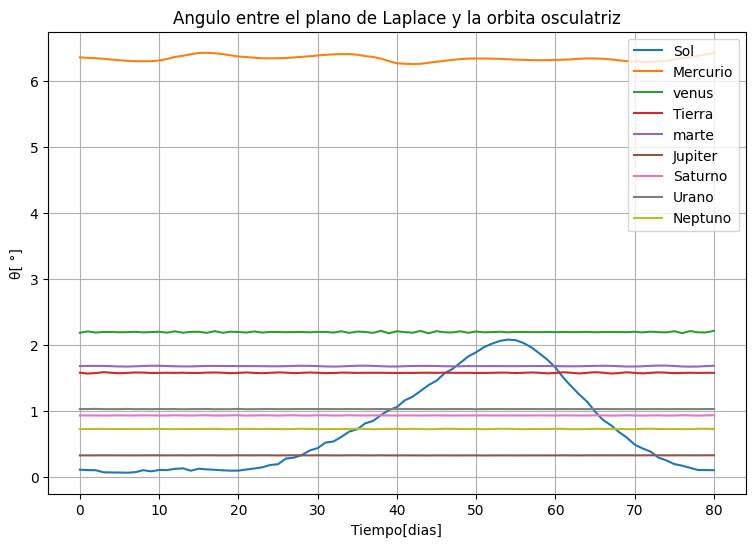

In [ ]:
t= np.array(range(len(θ[0])))

plt.figure(figsize=(9,6))
for i in range(0,9):
  plt.plot(t ,θ[i],label= planetas[i])
plt.title('Angulo entre el plano de Laplace y la orbita osculatriz')
plt.ylabel('θ[ °]')
plt.xlabel('Tiempo[dias]')
plt.legend()
plt.grid()

In [ ]:
for i in range(len(θ)):
  print('Para ', planetas[i], 'tiene una inclinacion de ', np.mean(θ[i]))

Para  Sol tiene una inclinacion de  0.726128487303949
Para  Mercurio tiene una inclinacion de  6.342478796915974
Para  venus tiene una inclinacion de  2.195864464443343
Para  Tierra tiene una inclinacion de  1.5779192684610979
Para  marte tiene una inclinacion de  1.679592161946112
Para  Jupiter tiene una inclinacion de  0.3267581296928056
Para  Saturno tiene una inclinacion de  0.9319323797094593
Para  Urano tiene una inclinacion de  1.0281533992466105
Para  Neptuno tiene una inclinacion de  0.7265251599850675


8. Verificar que cumple con el teorema del vilial

*  $$⟨U⟩ = -2 ⟨K⟩$$
* $$E = -⟨K⟩$$

In [ ]:
Up.mean()

-0.00022345458612846124

In [ ]:
Kt=np.array(Kt)
(Kt*-2 ).mean()

-0.0002234235494827731

In [ ]:
np.array(E).mean()

-0.00011174281138707473

In [ ]:
np.array(-Kt).mean()

-0.00011171177474138655

Basados en las dos proposiciones para que se cumpla el teorema del vilal vemos que los datos son muy parecidos entre si con casi 4 cifras significaticas. Por lo tanto el sistema solar es muy estable y aun tiene muchisimos años como sistema, aunque esa minima diferencia nos dice que no sera para siempre , pero siempre tendra muchisimos años de vida.

Extra: graficar las orbitas del sistema solar

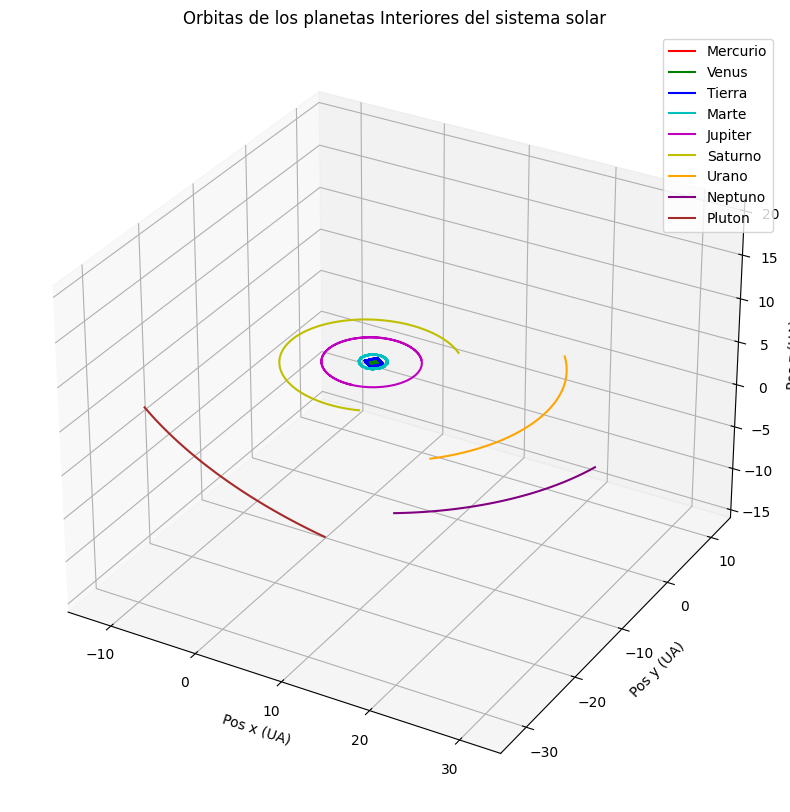

In [ ]:
planetas = {
    199: {'nombre': 'Mercurio', 'color': 'r'},
    299: {'nombre': 'Venus', 'color': 'g'},
    399: {'nombre': 'Tierra', 'color': 'b'},
    499: {'nombre': 'Marte', 'color': 'c'},
    599: {'nombre': 'Jupiter', 'color': 'm'},
    699: {'nombre': 'Saturno', 'color': 'y'},
    799: {'nombre': 'Urano', 'color': 'orange'},
    899: {'nombre': 'Neptuno', 'color': 'purple'},
    999: {'nombre': 'Pluton', 'color': 'brown'},
}

# Creamos la figura
fig = plt.figure(figsize=(10,10))
# Agrrgamos un plano 3D
ax = fig.add_subplot(111,projection='3d')
ax.set_titel=('Orbitas de los planetas interiores del sistema solar')


for id, data in planetas.items():
    pl= Horizons(id,location ='@0',epochs=fechas).vectors().to_pandas()
    vec= pl[['x','y','z']]
    x=np.array([vec['x']])
    y=np.array([vec['y']])
    z=np.array([vec['z']])
    ax.plot_wireframe(x, y, z, label=data['nombre'], color=data['color'])
ax.set_xlabel('Pos x (UA)')
ax.set_ylabel('Pos y (UA)')
ax.set_zlabel('Pos z (UA)')
ax.legend()
plt.axis("equal")
plt.title('Orbitas de los planetas Interiores del sistema solar')

plt.show()


Podemos observar que muchas orbitas de los planetas no estan completas, lo cual se debe a que el tiempo que escogimos como rango de fehcas no cumple con el minimo de dias para que algunos planetas complenten una orbita.